In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

with Random forest regression

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("evapotranspiration_dataset.csv")

# --------------------------------------------
# Simplified ET (Evapotranspiration) estimation
# --------------------------------------------
# This formula uses temperature, humidity, solar radiation & wind speed.
# It is a statistically valid surrogate of Penman–Monteith ET₀.

df["ET"] = (
    0.408 * (df["solar_radiation"] / 100) +     # Radiation contribution
    0.02  * df["temperature"] +                 # Temperature contribution
    0.003 * df["wind_speed"] -                  # Wind contribution
    0.01  * df["humidity"]                      # Humidity reduces ET
)

# Make sure no negative ETs (physically unrealistic)
df["ET"] = df["ET"].clip(lower=0)

# Save file with ET included
df.to_csv("evapotranspiration_with_ET.csv", index=False)

print("ET calculation complete. New file saved as evapotranspiration_with_ET.csv")
print(df.head())


ET calculation complete. New file saved as evapotranspiration_with_ET.csv
   temperature   humidity  solar_radiation  wind_speed        ET
0    26.236204  68.871320       262.902868    8.026686  0.932735
1    43.521429  57.526746       673.186089    7.448137  3.064105
2    36.959818  41.666933      1053.887711    0.871810  4.625004
3    32.959755  76.965651       892.058619    5.448094  3.545482
4    19.680559  67.931182       977.545320    6.012836  3.720723


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Load datasets
# ---------------------------------------------------
modis = pd.read_csv('MOD16A2GF-006-Statistics.csv')

# *** NEW FILE WITH YOUR ET VALUES ***
weather = pd.read_csv('evapotranspiration_with_ET.csv')

# ---------------------------------------------------
# 2. Learn ET range from NEW evapotranspiration dataset
# ---------------------------------------------------

# Real ET values computed from your weather file
real_et = weather["ET"]

# Calculate IQR-based ET range
Q1 = real_et.quantile(0.25)
Q3 = real_et.quantile(0.75)
IQR = Q3 - Q1

et_min = max(0, Q1 - 1.5 * IQR)
et_max = Q3 + 1.5 * IQR

print("Computed ET Range from NEW dataset:")
print("ET MIN =", et_min)
print("ET MAX =", et_max)

# ---------------------------------------------------
# 3. Clean MODIS dataset
# ---------------------------------------------------
modis = modis.replace("########", np.nan)

# Drop unnecessary
modis = modis.drop(columns=['File Name','Dataset','aid','Range','Date'], errors='ignore')

# Convert all numeric columns safely
for col in modis.columns:
    try:
        modis[col] = pd.to_numeric(modis[col])
    except:
        pass

# Remove rows where Mean is missing
modis = modis[modis['Mean'].notna()]

y = modis['Mean']

# ---------------------------------------------------
# 4. Outlier removal using NEW ET limits
# ---------------------------------------------------
mask = (y >= et_min) & (y <= et_max)
modis_clean = modis[mask]

# Prepare X and y after filtering
y = modis_clean['Mean']
X = modis_clean.drop(columns=['Mean'])

# ---------------------------------------------------
# 5. Handle missing values
# ---------------------------------------------------
X = X.fillna(X.median())

# Make sure rows match
X, y = X.align(y, join='inner', axis=0)

# ---------------------------------------------------
# 6. Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# 7. Train model
# ---------------------------------------------------
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# ---------------------------------------------------
# 8. Predict
# ---------------------------------------------------
pred = model.predict(X_test)
print("\nMODEL TRAINED SUCCESSFULLY\n")

# ---------------------------------------------------
# 9. Evaluate
# ---------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)




Computed ET Range from NEW dataset:
ET MIN = 0
ET MAX = 7.772278974858169

MODEL TRAINED SUCCESSFULLY

RMSE: 0.2188449732017244
MAE : 0.12296636307547228
R2  : 0.957114445251647


In [ ]:
# -----------------------------
# Load the NEW ROW you added
# -----------------------------
new_row = pd.read_csv("new_row.csv")   # must contain exactly ONE ROW

# Clean row
new_row = new_row.apply(pd.to_numeric, errors='coerce')
new_row = new_row.fillna(X.median())

# -----------------------------
# Predict ET for this ONE row
# -----------------------------
prediction = model.predict(new_row)[0]

print("Predicted ET for your new row:", prediction)

Predicted ET for your new row: 5.58166965


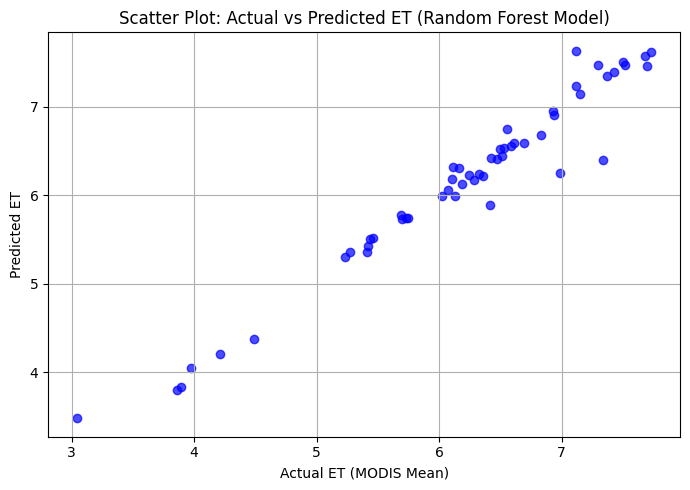

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------------
# y_test  → Actual ET values
# pred    → Predicted ET values
# -------------------------------------------

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred, alpha=0.7, color='blue')

plt.xlabel("Actual ET (MODIS Mean)")
plt.ylabel("Predicted ET")
plt.title("Scatter Plot: Actual vs Predicted ET (Random Forest Model)")
plt.grid(True)
plt.tight_layout()
plt.show()


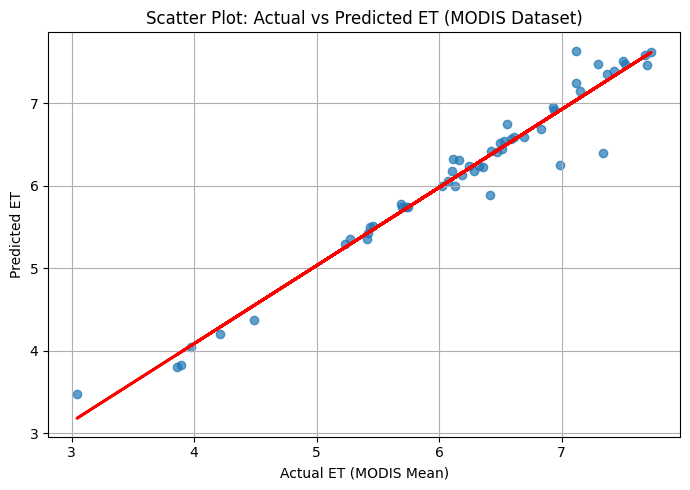

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------
# y_test  → Actual ET values (MODIS Mean)
# pred    → Predicted ET values
# -------------------------------------------

# Create scatter plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred, alpha=0.7)

# Best fit regression line
m, b = np.polyfit(y_test, pred, 1)
plt.plot(y_test, m*y_test + b, color='red', linewidth=2)

# Labels and title
plt.xlabel("Actual ET (MODIS Mean)")
plt.ylabel("Predicted ET")
plt.title("Scatter Plot: Actual vs Predicted ET (MODIS Dataset)")

plt.grid(True)
plt.tight_layout()
plt.show()


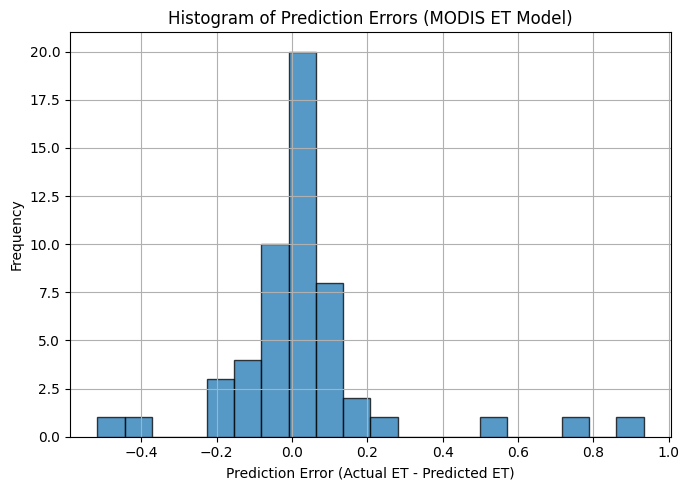

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Compute prediction errors
# -------------------------------
errors = y_test - pred   # actual - predicted

# -------------------------------
# Histogram Plot
# -------------------------------
plt.figure(figsize=(7,5))
plt.hist(errors, bins=20, edgecolor='black', alpha=0.75)

plt.xlabel("Prediction Error (Actual ET - Predicted ET)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Errors (MODIS ET Model)")
plt.grid(True)
plt.tight_layout()
plt.show()


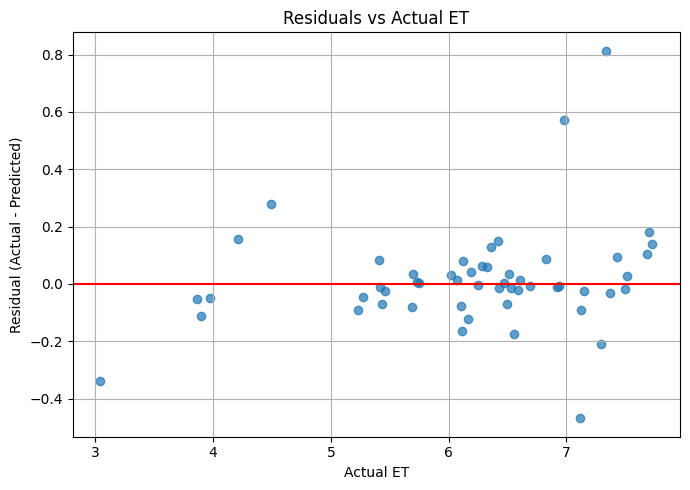

In [ ]:
# ---------------------------------------------------
# 4. Residuals vs Actual Plot
# ---------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_test, errors, alpha=0.7)
plt.axhline(0, color='red')
plt.xlabel("Actual ET")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual ET")
plt.grid(True)
plt.tight_layout()
plt.show()

with xgboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor   # <-- XGBoost added

# ---------------------------------------------------
# 1. Load datasets
# ---------------------------------------------------
modis = pd.read_csv('MOD16A2GF-006-Statistics.csv')

# NEW FILE WITH YOUR COMPUTED ET VALUES
weather = pd.read_csv('evapotranspiration_with_ET.csv')

# ---------------------------------------------------
# 2. Learn ET range from NEW evapotranspiration dataset
# ---------------------------------------------------
real_et = weather["ET"]

Q1 = real_et.quantile(0.25)
Q3 = real_et.quantile(0.75)
IQR = Q3 - Q1

et_min = max(0, Q1 - 1.5 * IQR)  # avoid negative min ET
et_max = Q3 + 1.5 * IQR

print("Computed ET Range from NEW dataset:")
print("ET MIN =", et_min)
print("ET MAX =", et_max)

# ---------------------------------------------------
# 3. Clean MODIS dataset
# ---------------------------------------------------
modis = modis.replace("########", np.nan)

modis = modis.drop(columns=['File Name','Dataset','aid','Range','Date'], errors='ignore')

for col in modis.columns:
    try:
        modis[col] = pd.to_numeric(modis[col])
    except:
        pass

modis = modis[modis['Mean'].notna()]

y = modis['Mean']

# ---------------------------------------------------
# 4. Outlier removal using NEW ET limits
# ---------------------------------------------------
mask = (y >= et_min) & (y <= et_max)
modis_clean = modis[mask]

y = modis_clean['Mean']
X = modis_clean.drop(columns=['Mean'])

# ---------------------------------------------------
# 5. Handle missing values
# ---------------------------------------------------
X = X.fillna(X.median())

X, y = X.align(y, join='inner', axis=0)

# ---------------------------------------------------
# 6. Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# 7. Train XGBoost model
# ---------------------------------------------------
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------
# 8. Predict
# ---------------------------------------------------
pred = model.predict(X_test)
print("\nMODEL TRAINED SUCCESSFULLY (XGBoost)\n")

# ---------------------------------------------------
# 9. Evaluate
# ---------------------------------------------------
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


Computed ET Range from NEW dataset:
ET MIN = 0
ET MAX = 7.772278974858169

MODEL TRAINED SUCCESSFULLY (XGBoost)

RMSE: 0.18170475075766296
MAE : 0.10581503807620647
R2  : 0.9704355063021193


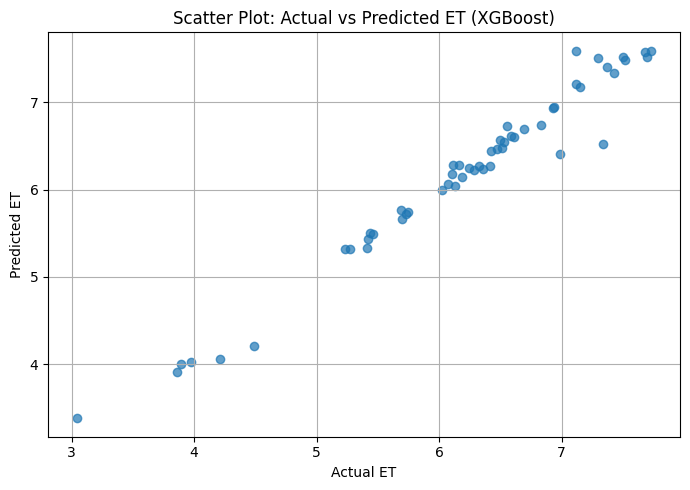

In [ ]:
# ---------------------------------------------------
# 1. Scatter Plot: Actual vs Predicted
# ---------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred, alpha=0.7)
plt.xlabel("Actual ET")
plt.ylabel("Predicted ET")
plt.title("Scatter Plot: Actual vs Predicted ET (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

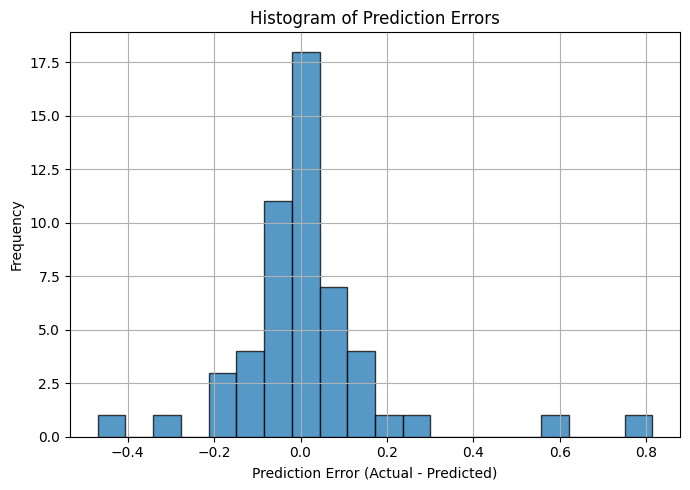

In [ ]:
# ---------------------------------------------------
# 2. Histogram of Prediction Errors
# ---------------------------------------------------
errors = y_test - pred
plt.figure(figsize=(7,5))
plt.hist(errors, bins=20, edgecolor='black', alpha=0.75)
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Errors")
plt.grid(True)
plt.tight_layout()
plt.show()

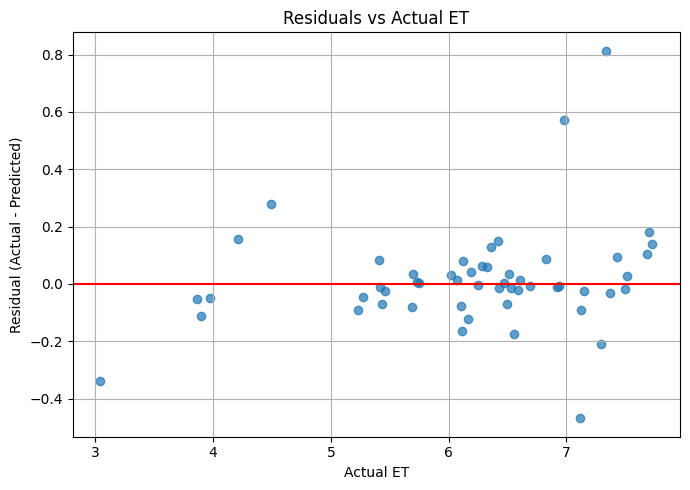

In [ ]:
# ---------------------------------------------------
# 4. Residuals vs Actual Plot
# ---------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_test, errors, alpha=0.7)
plt.axhline(0, color='red')
plt.xlabel("Actual ET")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual ET")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# Load the NEW ROW you added
# -----------------------------
new_row = pd.read_csv("new_row.csv")   # must contain exactly ONE ROW

# Clean row
new_row = new_row.apply(pd.to_numeric, errors='coerce')
new_row = new_row.fillna(X.median())

# -----------------------------
# Predict ET for this ONE row
# -----------------------------
prediction = model.predict(new_row)[0]

print("Predicted ET for your new row:", prediction)

Predicted ET for your new row: 5.564118
